# Do Kalshi MLB Game Winner Prices Reflect Accurate Probabilities?
If a YES contract trades at 45c just before first pitch, does that team win 45% of the time?

## Method
Compare Kalshi Prices to (empirical) probabilities from observed historical data.\
Note on terminology. If the prices match the probabilities we say the market is calibrated.

### Data Points
Each game contributes a single data point.\
Which is the last trade on its home team's market before the scheduled start.\
Note
- every game has two markets, one per team. their prices sum to about $1 (appendix A), so the away market carries no extra information and is dropped
- using a single data point per game avoids a problem of being overconfident by having a large sample size of highly correlated trades happening right next to each other
- restricted to the 24 hours before start, so stale quotes don't leak in
- For by inning view we use the last trade during the preceding inning. ie the price entering that inning
- the team and home vs away cuts need other slices of the data. each says which observations it uses

### Chart and Table Presentation
Data is displayed in price buckets. For different cuts.\
A cut is simply a way to break down the data in different ways, by filtering on things such as team or weather.
- 10c buckets for every cut

Every table shows the same columns in the same order.\
The first column is the bucket's price range, or the group name for grouped tables.

## Data
Data has been pulled from the official Kalshi API and MLB Stats API.\
An extensive write up on this data pull can be seen xxxxxxx.

The data date range is from\
April 16th 2025 - July 3rd 2026.\
This date range was chosen because Kalshi MLB markets started trading April 16th 2025, and I ran the last data pull on July 3rd 2026.\
The data covers 3,507 games and 7,028 markets.\
Note
- The 2025 MLB season started March 27th 2025
    - So we are missing ~3 weeks of data from the 2025 season.

## Potential Profit??????
If prices are off, there is money to be made.\
A team priced at 45c that actually wins 50% of the time earns 5c per contract on average.\
But Kalshi charges a taker fee of 7c × price × (1 − price), about 1.7c per contract at 45c (`wiki/kalshi-fees.md`).\
So a mispricing has to be bigger than the fee before it is profit. Roughly a 2c gap in the range where MLB games trade.\
The Costs section at the end does this math properly.

In [1]:
%matplotlib inline
from pathlib import Path

import duckdb
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import numpy as np
import polars as pl
from IPython.display import Markdown, display

con = duckdb.connect(Path("../db/pma.db"), read_only=True)

# one observation per game: the home-side market. appendix A shows the
# away side carries no extra information. cuts that need other slices
# (team, home vs away) query the full snapshot table and say so
con.sql("""
    CREATE OR REPLACE TEMP VIEW pre_home AS
    SELECT * FROM mlb_calib_pre_snapshots WHERE side = 'home'
""")

# chart chrome (light mode)
BLUE = "#2a78d6"     # series 1
AQUA = "#1baf7a"     # series 2
INK = "#0b0b0b"
MUTED = "#898781"
GRID = "#e1e0d9"
BASELINE = "#c3c2b7"
SURFACE = "#fcfcfb"

plt.rcParams.update({
    "figure.facecolor": SURFACE,
    "axes.facecolor": SURFACE,
    "axes.edgecolor": BASELINE,
    "axes.grid": True,
    "grid.color": GRID,
    "grid.linewidth": 0.6,
    "xtick.color": MUTED,
    "ytick.color": MUTED,
    "axes.labelcolor": MUTED,
    "text.color": INK,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.titlelocation": "left",
    "figure.dpi": 110,
})


def wilson(phat, n, z=1.96):
    """Wilson score interval for a proportion phat observed over n trials."""
    phat = np.asarray(phat, dtype=float)
    n = np.asarray(n, dtype=float)
    denom = 1 + z**2 / n
    center = (phat + z**2 / (2 * n)) / denom
    half = z * np.sqrt(phat * (1 - phat) / n + z**2 / (4 * n**2)) / denom
    return center - half, center + half


def with_deviation(df):
    """Deviation (win rate − avg price) with a 95% CI: the Wilson interval
    on the win rate, shifted by the average price."""
    lo, hi = wilson(df["win_rate"].to_numpy(), df["n_markets"].to_numpy())
    return df.with_columns(
        pl.Series("ci_lo", lo),
        pl.Series("ci_hi", hi),
        (pl.col("win_rate") - pl.col("avg_price")).alias("deviation"),
        (pl.Series(lo) - pl.col("avg_price")).alias("dev_lo"),
        (pl.Series(hi) - pl.col("avg_price")).alias("dev_hi"),
    )


def calibration(rel="pre_home", where="TRUE", buckets=10, params=None):
    """Calibration table over price buckets: one snapshot = one observation."""
    df = con.execute(f"""
        SELECT least(floor(p * {buckets}), {buckets - 1})::INT AS bucket,
               avg(p) AS avg_price,
               avg(y) AS win_rate,
               count(*) AS n_markets
        FROM {rel}
        WHERE {where}
        GROUP BY bucket ORDER BY bucket
    """, params).pl()
    return with_deviation(df)


def group_deviation(rel, expr, where="TRUE", order_by="grp"):
    """Aggregate deviation by a grouping expression: one row per group."""
    df = con.sql(f"""
        SELECT {expr} AS grp,
               count(*) AS n_markets,
               avg(p) AS avg_price,
               avg(y) AS win_rate
        FROM {rel}
        WHERE {where}
        GROUP BY grp ORDER BY {order_by}
    """).pl()
    return with_deviation(df)


def plot_calibration(ax, df, color=BLUE, label=None):
    """Calibration curve with Wilson error bars and the 45-degree line."""
    ax.plot([0, 1], [0, 1], ls="--", lw=1, color=BASELINE, zorder=1)
    x = df["avg_price"].to_numpy()
    y = df["win_rate"].to_numpy()
    yerr = np.vstack([y - df["ci_lo"].to_numpy(),
                      df["ci_hi"].to_numpy() - y])
    ax.errorbar(x, y, yerr=yerr, fmt="o-", ms=3.5, lw=1.5, color=color,
                elinewidth=1, capsize=2, label=label, zorder=3)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_aspect("equal")


PCT = mtick.PercentFormatter(xmax=1, decimals=0)

# table display: no dtype/shape clutter, human-formatted columns
pl.Config.set_tbl_hide_column_data_types(True)
pl.Config.set_tbl_hide_dataframe_shape(True)
pl.Config.set_tbl_rows(60)


def fmt_count(col):
    """Thousands-separated integer column."""
    return pl.col(col).map_elements(lambda n: f"{n:,}", return_dtype=pl.String)


def fmt_cents(col):
    return pl.format("{}¢", (pl.col(col) * 100).round(1))


def fmt_pct(col):
    return pl.format("{}%", (pl.col(col) * 100).round(1))


def fmt_signed_cents(col):
    v = (pl.col(col) * 100).round(1)
    return (pl.when(v > 0).then(pl.format("+{}¢", v))
              .when(v < 0).then(pl.format("{}¢", v))
              .otherwise(pl.lit("+0.0¢")))  # catches -0.0


def show_table(df, first):
    """The standard table: a name column, then the same columns everywhere."""
    return df.select(
        first,
        fmt_cents("avg_price").alias("avg price"),
        fmt_pct("win_rate").alias("win rate"),
        fmt_signed_cents("deviation").alias("win − price"),
        pl.format("[{}¢, {}¢]",
                  (pl.col("dev_lo") * 100).round(1),
                  (pl.col("dev_hi") * 100).round(1))
            .alias("95% CI (win − price)"),
        fmt_count("n_markets").alias("markets"),
    )


def show_calibration(df, buckets=10):
    """Standard table for a bucketed calibration table."""
    step = 100 // buckets
    lo = pl.col("bucket") * step
    return show_table(
        df, pl.format("{}–{}¢", lo, lo + step).alias("price range"))


def show_group(df, name_col):
    """Standard table for a grouped deviation table."""
    return show_table(df, pl.col(name_col))

## Cut 1 - Pre-Game Calibration, 10c Buckets

One snapshot per game, the home-side market just before first pitch.\
Note
- pre-game MLB prices live almost entirely between 25c and 75c. teams are rarely bigger than 3:1 favorites before the game starts
- so the tails of this curve are nearly empty and their intervals are wide

Method checks live in the appendix, the main flow only uses their conclusions
- the two markets of a game price to about $1, so the home side carries all the information (appendix A)
- the snapshot is fresh. median age at first pitch is 1 minute (appendix B)
- the effective spread is one tick, so a print sits within about half a cent of the market's estimate (appendix C)

In [2]:
overall = calibration()
show_calibration(overall)

price range,avg price,win rate,win − price,95% CI (win − price),markets
"""0–10¢""","""1.6¢""","""0.0%""","""-1.6¢""","""[-1.6¢, 41.8¢]""","""5"""
"""20–30¢""","""27.8¢""","""38.1%""","""+10.3¢""","""[-7.1¢, 31.3¢]""","""21"""
"""30–40¢""","""36.3¢""","""36.7%""","""+0.4¢""","""[-6.3¢, 7.6¢]""","""180"""
"""40–50¢""","""45.4¢""","""48.5%""","""+3.1¢""","""[-0.1¢, 6.4¢]""","""892"""
"""50–60¢""","""54.5¢""","""53.7%""","""-0.9¢""","""[-3.4¢, 1.6¢]""","""1,532"""
"""60–70¢""","""63.3¢""","""58.2%""","""-5.1¢""","""[-8.8¢, -1.6¢]""","""717"""
"""70–80¢""","""72.6¢""","""73.1%""","""+0.4¢""","""[-7.0¢, 6.8¢]""","""156"""
"""80–90¢""","""80.0¢""","""100.0%""","""+20.0¢""","""[-45.8¢, 20.0¢]""","""2"""
"""90–100¢""","""99.0¢""","""100.0%""","""+1.0¢""","""[-64.8¢, 1.0¢]""","""2"""


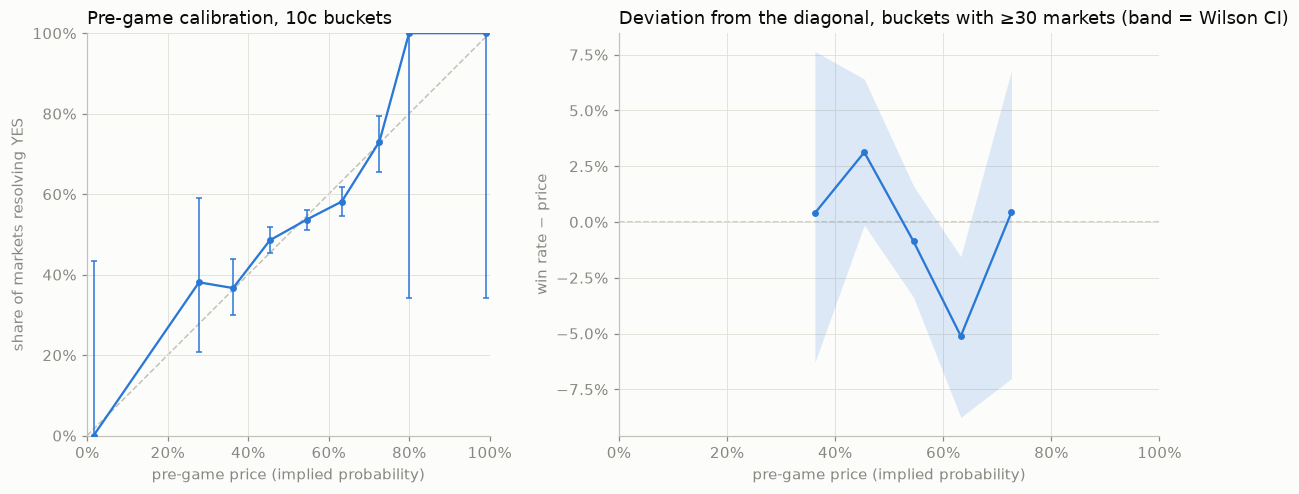

In [3]:
fig, (ax1, ax2) = plt.subplots(
    1, 2, figsize=(11, 4.6), gridspec_kw={"width_ratios": [1, 1.3]})

plot_calibration(ax1, overall)
ax1.set_xlabel("pre-game price (implied probability)")
ax1.set_ylabel("share of markets resolving YES")
ax1.set_title("Pre-game calibration, 10c buckets", color=INK)
ax1.xaxis.set_major_formatter(PCT)
ax1.yaxis.set_major_formatter(PCT)

dense = overall.filter(pl.col("n_markets") >= 30)
x = dense["avg_price"].to_numpy()
dev = dense["deviation"].to_numpy()
lo = dense["dev_lo"].to_numpy()
hi = dense["dev_hi"].to_numpy()
ax2.axhline(0, ls="--", lw=1, color=BASELINE, zorder=1)
ax2.fill_between(x, lo, hi, color=BLUE, alpha=0.15, lw=0, zorder=2)
ax2.plot(x, dev, "o-", ms=3.5, lw=1.5, color=BLUE, zorder=3)
ax2.set_xlim(0, 1)
ax2.set_xlabel("pre-game price (implied probability)")
ax2.set_ylabel("win rate − price")
ax2.set_title("Deviation from the diagonal, buckets with ≥30 markets "
              "(band = Wilson CI)", color=INK)
ax2.xaxis.set_major_formatter(PCT)
ax2.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1, decimals=1))

fig.tight_layout()
plt.show()

In [4]:
# buckets whose 95% CI on win − price excludes zero
sig = overall.filter((pl.col("dev_lo") > 0) | (pl.col("dev_hi") < 0))
show_calibration(sig)

price range,avg price,win rate,win − price,95% CI (win − price),markets
"""60–70¢""","""63.3¢""","""58.2%""","""-5.1¢""","""[-8.8¢, -1.6¢]""","""717"""


## Cut 2 - Pre-Game, Then Entering Each Inning

The pre-game panel repeats Cut 1.\
The rest show the price entering innings 2-9 and extras (entering the 10th).\
Home-side snapshots, one per game and inning.\
Note
- a game appears in a panel only if its market traded during the preceding inning. coverage stays near complete throughout (counts in each panel)

In [5]:
PHASES = (["pre-game"]
          + [f"entering {i}" for i in range(2, 10)]
          + ["extras"])


def phase_calibration(phase, buckets=10):
    if phase == "pre-game":
        return calibration(buckets=buckets)
    if phase == "extras":
        return calibration("mlb_calib_inning_snapshots",
                           "side = 'home' AND entering = 10",
                           buckets=buckets)
    return calibration("mlb_calib_inning_snapshots",
                       "side = 'home' AND entering = ?",
                       buckets=buckets,
                       params=[int(phase.split()[1])])


for phase in PHASES:
    df = phase_calibration(phase)
    display(Markdown(f"**{phase}**, {df['n_markets'].sum():,} markets"))
    display(show_calibration(df, buckets=10))

**pre-game**, 3,507 markets

price range,avg price,win rate,win − price,95% CI (win − price),markets
"""0–10¢""","""1.6¢""","""0.0%""","""-1.6¢""","""[-1.6¢, 41.8¢]""","""5"""
"""20–30¢""","""27.8¢""","""38.1%""","""+10.3¢""","""[-7.1¢, 31.3¢]""","""21"""
"""30–40¢""","""36.3¢""","""36.7%""","""+0.4¢""","""[-6.3¢, 7.6¢]""","""180"""
"""40–50¢""","""45.4¢""","""48.5%""","""+3.1¢""","""[-0.1¢, 6.4¢]""","""892"""
"""50–60¢""","""54.5¢""","""53.7%""","""-0.9¢""","""[-3.4¢, 1.6¢]""","""1,532"""
"""60–70¢""","""63.3¢""","""58.2%""","""-5.1¢""","""[-8.8¢, -1.6¢]""","""717"""
"""70–80¢""","""72.6¢""","""73.1%""","""+0.4¢""","""[-7.0¢, 6.8¢]""","""156"""
"""80–90¢""","""80.0¢""","""100.0%""","""+20.0¢""","""[-45.8¢, 20.0¢]""","""2"""
"""90–100¢""","""99.0¢""","""100.0%""","""+1.0¢""","""[-64.8¢, 1.0¢]""","""2"""


**entering 2**, 3,494 markets

price range,avg price,win rate,win − price,95% CI (win − price),markets
"""0–10¢""","""7.0¢""","""15.0%""","""+8.0¢""","""[-1.8¢, 29.0¢]""","""20"""
"""10–20¢""","""15.9¢""","""12.5%""","""-3.4¢""","""[-9.4¢, 6.9¢]""","""64"""
"""20–30¢""","""24.9¢""","""21.4%""","""-3.5¢""","""[-9.4¢, 4.1¢]""","""140"""
"""30–40¢""","""35.4¢""","""34.6%""","""-0.8¢""","""[-5.8¢, 4.6¢]""","""321"""
"""40–50¢""","""45.2¢""","""45.0%""","""-0.1¢""","""[-3.8¢, 3.6¢]""","""684"""
"""50–60¢""","""54.5¢""","""55.1%""","""+0.6¢""","""[-2.4¢, 3.7¢]""","""1,034"""
"""60–70¢""","""64.1¢""","""59.3%""","""-4.8¢""","""[-8.6¢, -1.0¢]""","""649"""
"""70–80¢""","""73.6¢""","""69.0%""","""-4.6¢""","""[-9.7¢, -0.0¢]""","""348"""
"""80–90¢""","""84.0¢""","""86.4%""","""+2.4¢""","""[-3.2¢, 6.5¢]""","""191"""
"""90–100¢""","""92.8¢""","""86.0%""","""-6.8¢""","""[-20.1¢, 0.6¢]""","""43"""


**entering 3**, 3,486 markets

...

price range,avg price,win rate,win − price,95% CI (win − price),markets
"""0–10¢""","""3.7¢""","""3.1%""","""-0.6¢""","""[-1.6¢, 0.8¢]""","""782"""
"""10–20¢""","""13.3¢""","""11.4%""","""-1.9¢""","""[-5.0¢, 2.2¢]""","""298"""
"""20–30¢""","""24.2¢""","""26.6%""","""+2.4¢""","""[-2.2¢, 7.6¢]""","""312"""
"""30–40¢""","""32.9¢""","""30.9%""","""-2.0¢""","""[-12.6¢, 11.1¢]""","""55"""
"""40–50¢""","""46.5¢""","""47.3%""","""+0.7¢""","""[-7.7¢, 9.3¢]""","""129"""
"""50–60¢""","""53.9¢""","""52.7%""","""-1.2¢""","""[-7.8¢, 5.2¢]""","""224"""
"""60–70¢""","""63.8¢""","""73.3%""","""+9.5¢""","""[-4.8¢, 20.2¢]""","""45"""
"""70–80¢""","""75.7¢""","""78.2%""","""+2.5¢""","""[-3.4¢, 7.4¢]""","""225"""
"""80–90¢""","""84.7¢""","""83.2%""","""-1.5¢""","""[-6.1¢, 2.2¢]""","""315"""
"""90–100¢""","""96.2¢""","""96.7%""","""+0.5¢""","""[-0.8¢, 1.4¢]""","""1,064"""


**entering 9**, 3,399 markets

price range,avg price,win rate,win − price,95% CI (win − price),markets
"""0–10¢""","""3.2¢""","""2.5%""","""-0.7¢""","""[-1.4¢, 0.5¢]""","""1,071"""
"""10–20¢""","""14.6¢""","""16.7%""","""+2.1¢""","""[-1.5¢, 6.6¢]""","""323"""
"""20–30¢""","""22.3¢""","""15.2%""","""-7.1¢""","""[-15.6¢, 8.7¢]""","""33"""
"""30–40¢""","""32.8¢""","""25.0%""","""-7.8¢""","""[-28.2¢, 37.2¢]""","""4"""
"""40–50¢""","""46.5¢""","""48.2%""","""+1.6¢""","""[-7.5¢, 10.9¢]""","""110"""
"""50–60¢""","""53.4¢""","""48.8%""","""-4.6¢""","""[-11.3¢, 2.1¢]""","""211"""
"""60–70¢""","""63.0¢""","""59.1%""","""-3.9¢""","""[-24.2¢, 13.8¢]""","""22"""
"""70–80¢""","""77.4¢""","""85.7%""","""+8.4¢""","""[-17.3¢, 18.6¢]""","""14"""
"""80–90¢""","""86.0¢""","""87.1%""","""+1.0¢""","""[-3.3¢, 4.4¢]""","""294"""
"""90–100¢""","""97.3¢""","""97.9%""","""+0.6¢""","""[-0.3¢, 1.3¢]""","""1,317"""


**extras**, 302 markets

price range,avg price,win rate,win − price,95% CI (win − price),markets
"""30–40¢""","""37.7¢""","""66.7%""","""+29.0¢""","""[-16.9¢, 56.2¢]""","""3"""
"""40–50¢""","""46.4¢""","""50.4%""","""+4.0¢""","""[-5.1¢, 13.1¢]""","""113"""
"""50–60¢""","""53.4¢""","""52.3%""","""-1.1¢""","""[-8.5¢, 6.2¢]""","""172"""
"""60–70¢""","""62.4¢""","""41.7%""","""-20.7¢""","""[-43.0¢, 5.7¢]""","""12"""
"""70–80¢""","""77.0¢""","""100.0%""","""+23.0¢""","""[-56.3¢, 23.0¢]""","""1"""
"""80–90¢""","""86.0¢""","""100.0%""","""+14.0¢""","""[-65.3¢, 14.0¢]""","""1"""


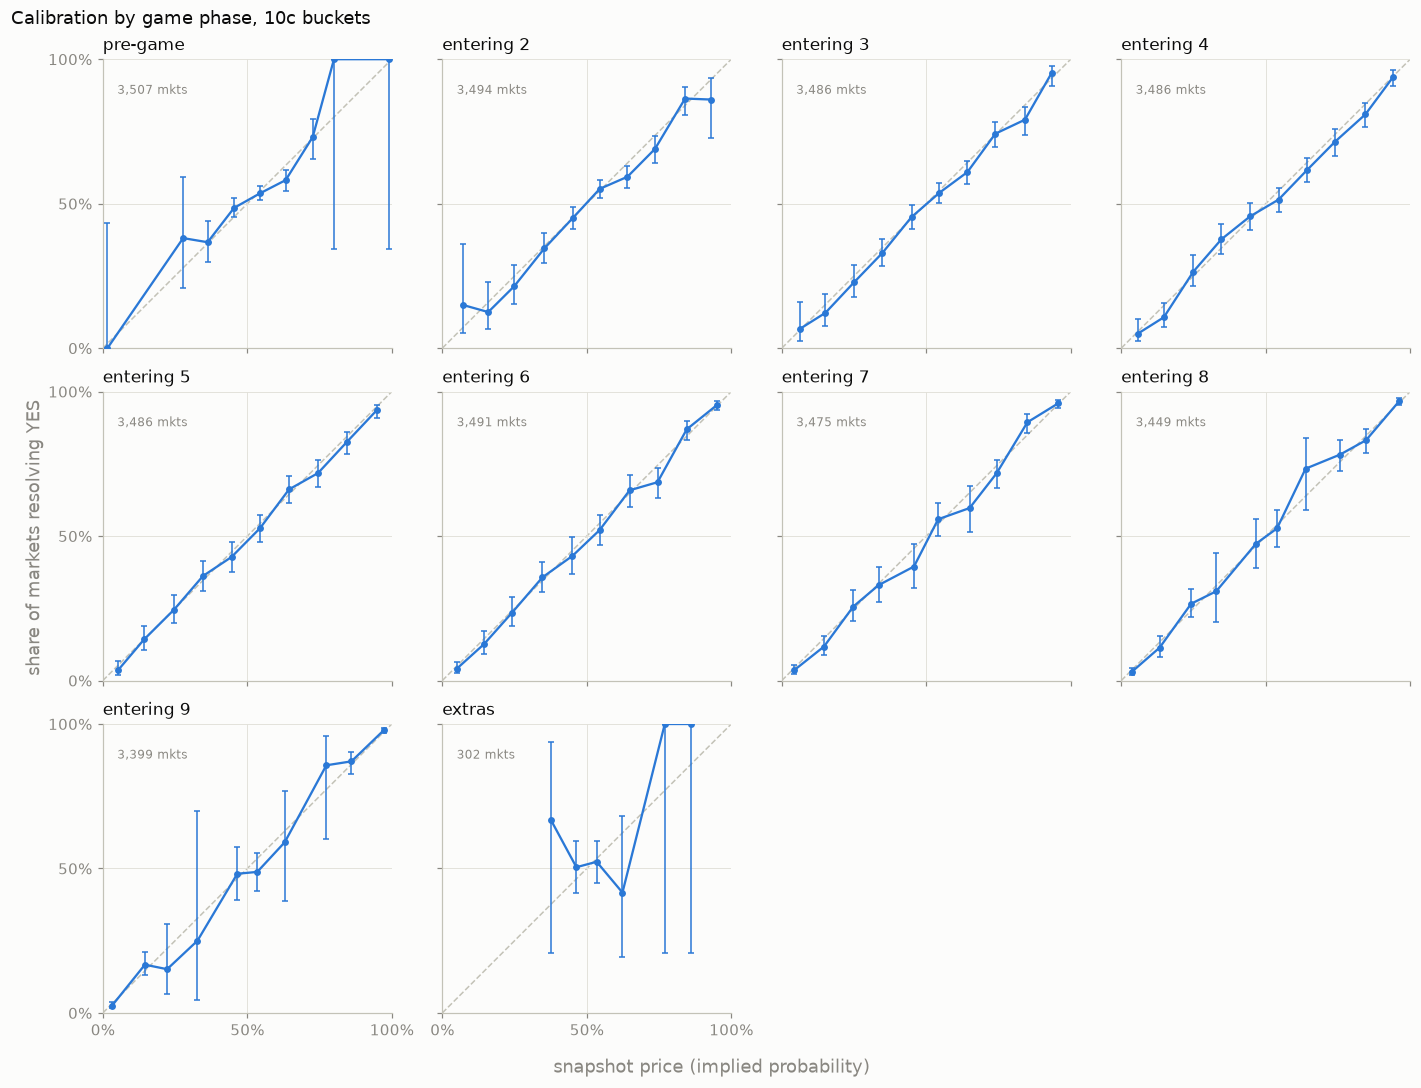

In [6]:
fig, axes = plt.subplots(3, 4, figsize=(13, 10), sharex=True, sharey=True)

for ax, phase in zip(axes.flat, PHASES):
    df = phase_calibration(phase)
    plot_calibration(ax, df)
    ax.set_title(phase, color=INK, fontsize=11)
    ax.annotate(f"{df['n_markets'].sum():,} mkts", (0.05, 0.88),
                xycoords="axes fraction", fontsize=8, color=MUTED)
    ax.set_xticks([0, 0.5, 1])
    ax.set_yticks([0, 0.5, 1])
    ax.xaxis.set_major_formatter(PCT)
    ax.yaxis.set_major_formatter(PCT)

for ax in axes.flat[len(PHASES):]:
    ax.set_visible(False)
fig.supxlabel("snapshot price (implied probability)", color=MUTED)
fig.supylabel("share of markets resolving YES", color=MUTED)
fig.suptitle("Calibration by game phase, 10c buckets", color=INK, x=0.01,
             ha="left")
fig.tight_layout()
plt.show()

## Cut 3 - By Team

Pre-game snapshots only.\
Each market's YES side is one team winning, so every snapshot belongs to exactly one team.\
This cut uses both markets of each game: a team's snapshots are the markets where it is the YES team, home or away.\
Within a team that is still one observation per game.\
Note
- with only ~230 markets per team, the per-bucket curves are indicative at best. the table's aggregate deviation (win rate minus average price) is the readable statistic
- at 95% confidence, one or two of thirty intervals excluding zero is what chance alone produces

In [7]:
teams = (group_deviation("mlb_calib_pre_snapshots", "team")
         .rename({"grp": "team"})
         .sort("deviation", descending=True))
show_group(teams, "team")

team,avg price,win rate,win − price,95% CI (win − price),markets
"""Milwaukee""","""54.2¢""","""60.6%""","""+6.4¢""","""[0.1¢, 12.4¢]""","""236"""
"""Cleveland""","""49.3¢""","""53.4%""","""+4.1¢""","""[-2.3¢, 10.3¢]""","""236"""
"""Miami""","""46.2¢""","""50.2%""","""+4.0¢""","""[-2.4¢, 10.4¢]""","""233"""
"""Chicago WS""","""41.0¢""","""43.5%""","""+2.5¢""","""[-3.7¢, 8.9¢]""","""232"""
"""Toronto""","""52.0¢""","""54.3%""","""+2.2¢""","""[-4.0¢, 8.3¢]""","""247"""
"""St. Louis""","""48.2¢""","""50.2%""","""+2.1¢""","""[-4.4¢, 8.5¢]""","""229"""
"""Washington""","""42.8¢""","""44.8%""","""+2.0¢""","""[-4.2¢, 8.5¢]""","""232"""
"""Tampa Bay""","""51.0¢""","""52.2%""","""+1.2¢""","""[-5.3¢, 7.6¢]""","""228"""
"""Philadelphia""","""56.7¢""","""57.4%""","""+0.7¢""","""[-5.7¢, 6.8¢]""","""237"""
"""Chicago C""","""55.5¢""","""56.2%""","""+0.6¢""","""[-5.7¢, 6.8¢]""","""235"""


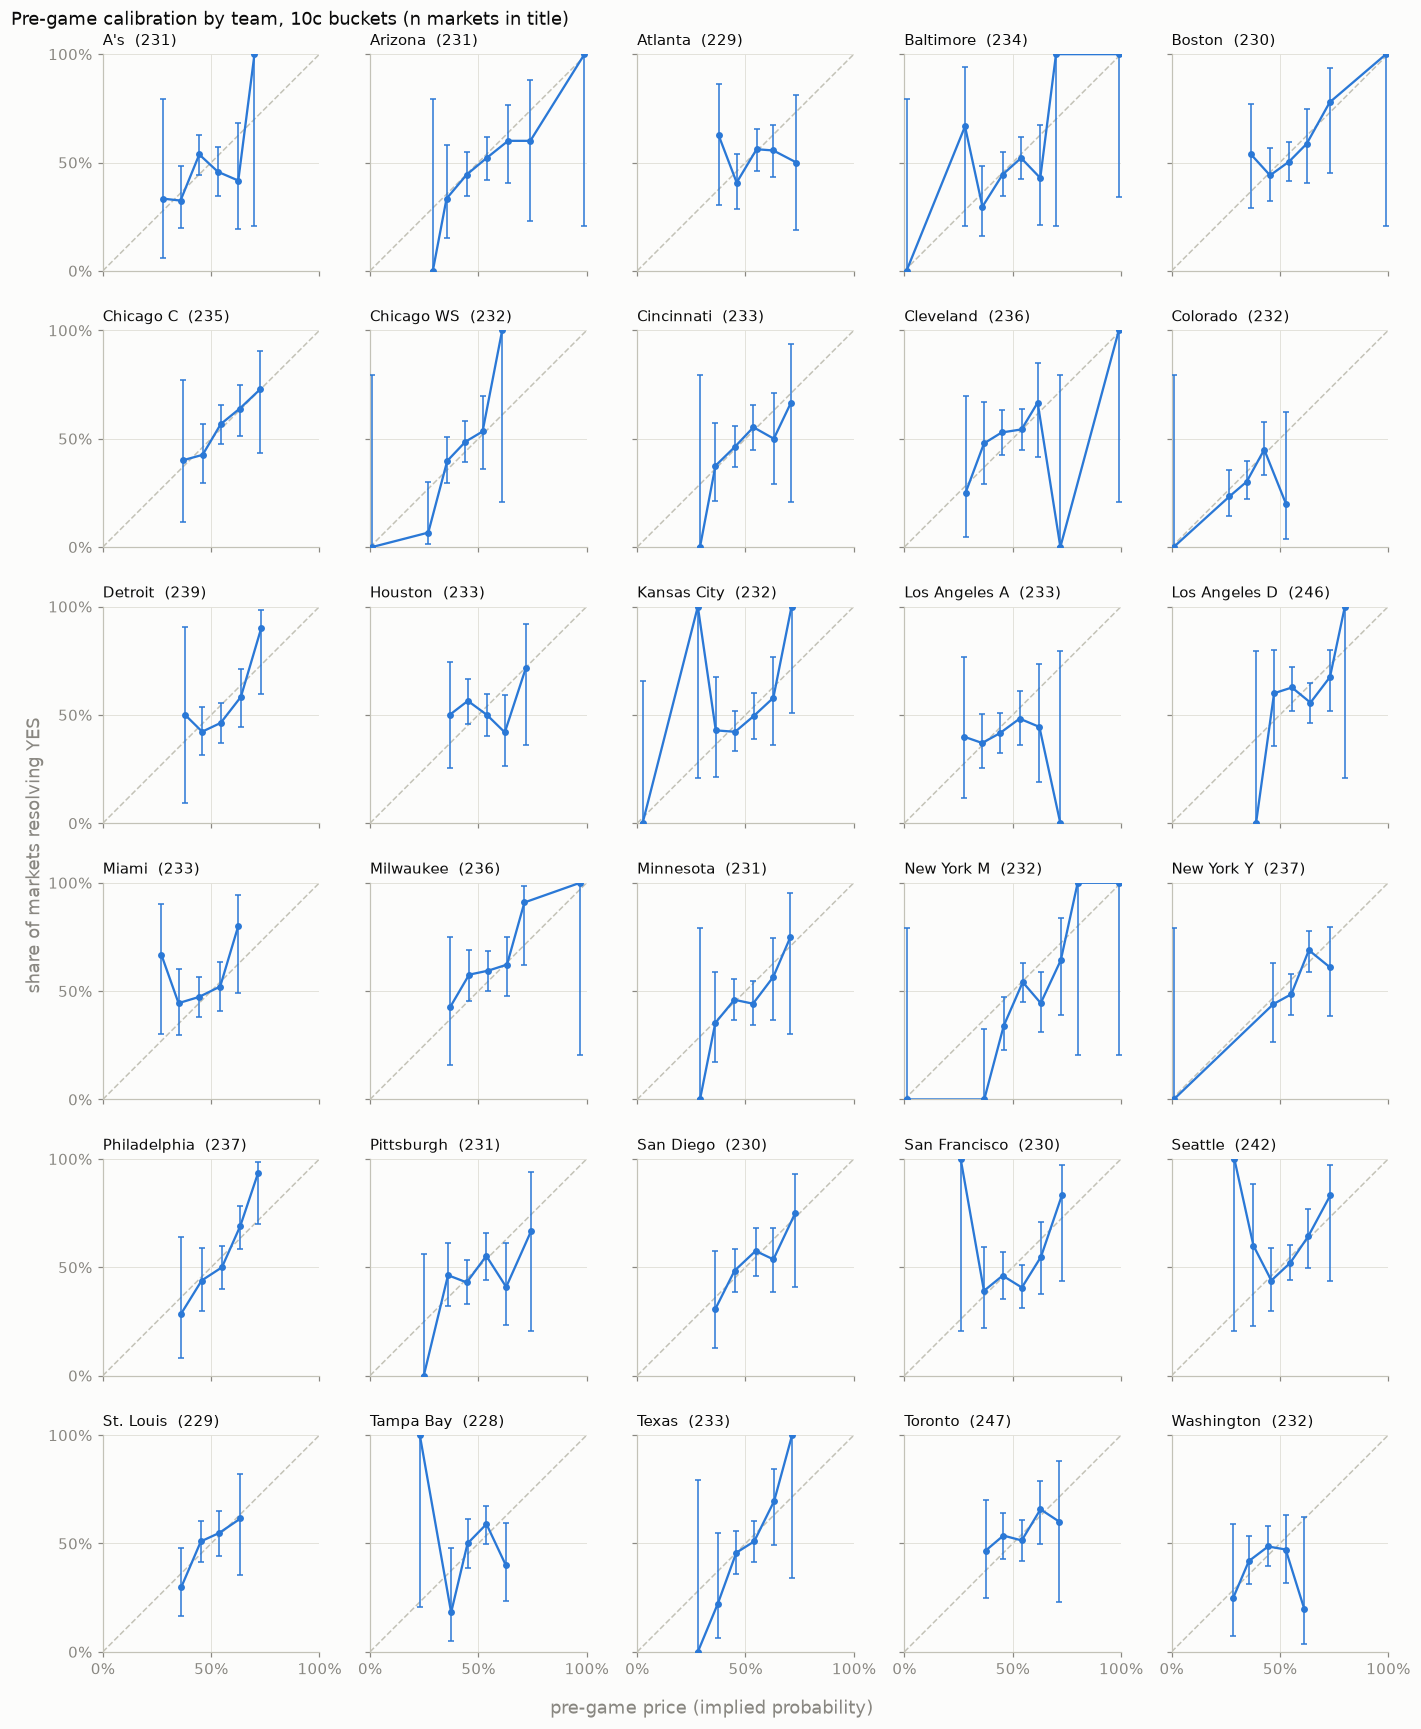

In [8]:
fig, axes = plt.subplots(6, 5, figsize=(13, 16), sharex=True, sharey=True)

for ax, team in zip(axes.flat, teams.sort("team")["team"]):
    df = calibration("mlb_calib_pre_snapshots", "team = ?", buckets=10,
                     params=[team])
    plot_calibration(ax, df)
    n = teams.filter(pl.col("team") == team)["n_markets"][0]
    ax.set_title(f"{team}  ({n})", color=INK, fontsize=10)
    ax.set_xticks([0, 0.5, 1])
    ax.set_yticks([0, 0.5, 1])
    ax.xaxis.set_major_formatter(PCT)
    ax.yaxis.set_major_formatter(PCT)

fig.supxlabel("pre-game price (implied probability)", color=MUTED)
fig.supylabel("share of markets resolving YES", color=MUTED)
fig.suptitle("Pre-game calibration by team, 10c buckets "
             "(n markets in title)", color=INK, x=0.01, ha="left")
fig.tight_layout()
plt.show()

### Team × Home/Away

The same aggregate deviation, one cell per team and side.\
A screen, not a test.\
Note
- ~115 markets per cell puts each 95% interval at roughly ±9c
- 60 intervals at 95% produce ~3 exclusions by chance alone. zero to four flagged cells says nothing
- a cluster would warrant a follow-up. one team flagged on both sides, or far more than ~3 flags

In [9]:
team_side = (group_deviation("mlb_calib_pre_snapshots",
                             "team || ', ' || side")
             .rename({"grp": "team, side"}))
n_flag = team_side.filter(
    (pl.col("dev_lo") > 0) | (pl.col("dev_hi") < 0)).height
print(f"intervals excluding zero: {n_flag} of {team_side.height}")
show_group(team_side, "team, side")

intervals excluding zero: 2 of 60


"team, side",avg price,win rate,win − price,95% CI (win − price),markets
"""A's, away""","""43.7¢""","""48.7%""","""+5.0¢""","""[-4.0¢, 14.0¢]""","""115"""
"""A's, home""","""49.4¢""","""45.7%""","""-3.7¢""","""[-12.5¢, 5.4¢]""","""116"""
"""Arizona, away""","""46.9¢""","""43.1%""","""-3.8¢""","""[-12.5¢, 5.3¢]""","""116"""
"""Arizona, home""","""54.5¢""","""54.8%""","""+0.3¢""","""[-8.8¢, 9.1¢]""","""115"""
"""Atlanta, away""","""52.4¢""","""53.1%""","""+0.7¢""","""[-8.4¢, 9.7¢]""","""113"""
"""Atlanta, home""","""57.5¢""","""51.7%""","""-5.8¢""","""[-14.8¢, 3.1¢]""","""116"""
"""Baltimore, away""","""45.6¢""","""42.9%""","""-2.8¢""","""[-11.6¢, 6.5¢]""","""112"""
"""Baltimore, home""","""52.0¢""","""50.0%""","""-2.0¢""","""[-10.8¢, 6.7¢]""","""122"""
"""Boston, away""","""49.8¢""","""50.9%""","""+1.0¢""","""[-8.1¢, 10.1¢]""","""112"""
"""Boston, home""","""55.9¢""","""51.7%""","""-4.2¢""","""[-13.1¢, 4.6¢]""","""118"""


## Cut 4 - Home vs Away

Pre-game snapshots split by whether the market's YES team is the home team (the `side` column, orientation verified during the pull).\
This cut needs both markets of each game by definition, so it is the one place the away-side snapshots come back in.\
The two curves use disjoint markets, so a home team bias would show up here.

In [10]:
sides = (group_deviation("mlb_calib_pre_snapshots", "side")
         .rename({"grp": "side"}))
show_group(sides, "side")

side,avg price,win rate,win − price,95% CI (win − price),markets
"""away""","""47.5¢""","""46.8%""","""-0.6¢""","""[-2.3¢, 1.0¢]""","""3,507"""
"""home""","""53.7¢""","""53.2%""","""-0.5¢""","""[-2.2¢, 1.1¢]""","""3,507"""


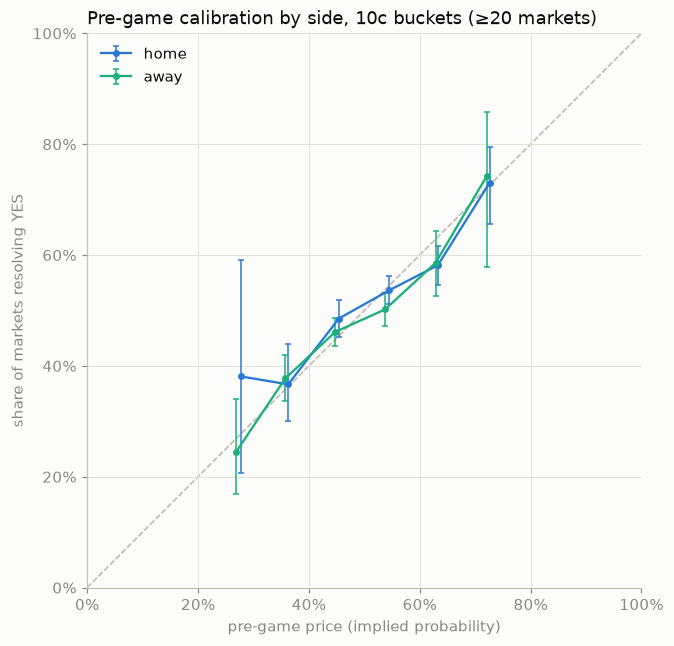

In [11]:
fig, ax = plt.subplots(figsize=(6.2, 6.2))

home = calibration("mlb_calib_pre_snapshots", "side = 'home'")
away = calibration("mlb_calib_pre_snapshots", "side = 'away'")
# tails hold 1-2 markets per bucket; plot only buckets with real sample
plot_calibration(ax, home.filter(pl.col("n_markets") >= 20),
                 color=BLUE, label="home")
plot_calibration(ax, away.filter(pl.col("n_markets") >= 20),
                 color=AQUA, label="away")

ax.set_xlabel("pre-game price (implied probability)")
ax.set_ylabel("share of markets resolving YES")
ax.set_title("Pre-game calibration by side, 10c buckets (≥20 markets)",
             color=INK)
ax.xaxis.set_major_formatter(PCT)
ax.yaxis.set_major_formatter(PCT)
ax.legend(loc="upper left", frameon=False)

fig.tight_layout()
plt.show()

In [12]:
# per-bucket home/away tables for the record
display(Markdown("**home**"))
display(show_calibration(home))
display(Markdown("**away**"))
display(show_calibration(away))

**home**

price range,avg price,win rate,win − price,95% CI (win − price),markets
"""0–10¢""","""1.6¢""","""0.0%""","""-1.6¢""","""[-1.6¢, 41.8¢]""","""5"""
"""20–30¢""","""27.8¢""","""38.1%""","""+10.3¢""","""[-7.1¢, 31.3¢]""","""21"""
"""30–40¢""","""36.3¢""","""36.7%""","""+0.4¢""","""[-6.3¢, 7.6¢]""","""180"""
"""40–50¢""","""45.4¢""","""48.5%""","""+3.1¢""","""[-0.1¢, 6.4¢]""","""892"""
"""50–60¢""","""54.5¢""","""53.7%""","""-0.9¢""","""[-3.4¢, 1.6¢]""","""1,532"""
"""60–70¢""","""63.3¢""","""58.2%""","""-5.1¢""","""[-8.8¢, -1.6¢]""","""717"""
"""70–80¢""","""72.6¢""","""73.1%""","""+0.4¢""","""[-7.0¢, 6.8¢]""","""156"""
"""80–90¢""","""80.0¢""","""100.0%""","""+20.0¢""","""[-45.8¢, 20.0¢]""","""2"""
"""90–100¢""","""99.0¢""","""100.0%""","""+1.0¢""","""[-64.8¢, 1.0¢]""","""2"""


**away**

price range,avg price,win rate,win − price,95% CI (win − price),markets
"""0–10¢""","""1.0¢""","""0.0%""","""-1.0¢""","""[-1.0¢, 64.8¢]""","""2"""
"""20–30¢""","""26.9¢""","""24.5%""","""-2.4¢""","""[-10.0¢, 7.2¢]""","""94"""
"""30–40¢""","""35.8¢""","""37.8%""","""+2.0¢""","""[-2.0¢, 6.2¢]""","""535"""
"""40–50¢""","""44.8¢""","""46.2%""","""+1.4¢""","""[-1.2¢, 3.9¢]""","""1,456"""
"""50–60¢""","""53.7¢""","""50.2%""","""-3.6¢""","""[-6.5¢, -0.6¢]""","""1,112"""
"""60–70¢""","""62.9¢""","""58.6%""","""-4.3¢""","""[-10.3¢, 1.5¢]""","""268"""
"""70–80¢""","""72.1¢""","""74.3%""","""+2.2¢""","""[-14.2¢, 13.7¢]""","""35"""
"""90–100¢""","""98.6¢""","""100.0%""","""+1.4¢""","""[-42.0¢, 1.4¢]""","""5"""


## Cut 5 - Stability Over Time

Is the pre-game miscalibration an artifact of one stretch of games?\
Month by month is too thin to answer. Roughly 350 snapshots a month leaves ~120 in the 55-65c band and intervals of about ±9c.\
So each season is instead split in half at its median game date, giving four periods of 650-1,100 snapshots.\
The focused test tracks favorites at 55-65c (overlapping the 60-70c bucket Cut 1 flags) and underdogs at 35-45c.\
Note
- home-side snapshots, like the rest of the notebook. the two regions are different games, not mirrors of the same ones
- compression (prices too extreme) predicts a negative deviation for the favorites and a positive one for the underdogs

In [13]:
con.sql("""
    CREATE OR REPLACE TEMP VIEW pre_snap_period AS
    SELECT game_pk, season, p, y, sched_start,
           CASE WHEN sched_start <= median(sched_start)
                    OVER (PARTITION BY season)
                THEN 'early' ELSE 'late' END AS half
    FROM pre_home
""")

PERIODS = [(2025, "early"), (2025, "late"), (2026, "early"), (2026, "late")]

con.sql("""
    SELECT season, half,
           min(sched_start)::DATE AS first_game,
           max(sched_start)::DATE AS last_game,
           count(*) AS n_markets
    FROM pre_snap_period
    GROUP BY season, half ORDER BY season, half
""").pl().select(
    pl.format("{} {}", pl.col("season"), pl.col("half")).alias("period"),
    pl.col("first_game"),
    pl.col("last_game"),
    fmt_count("n_markets").alias("markets"),
)

period,first_game,last_game,markets
"""2025 early""",2025-04-16,2025-07-08,"""1,103"""
"""2025 late""",2025-07-08,2025-11-01,"""1,100"""
"""2026 early""",2026-03-26,2026-05-14,"""652"""
"""2026 late""",2026-05-14,2026-07-03,"""652"""


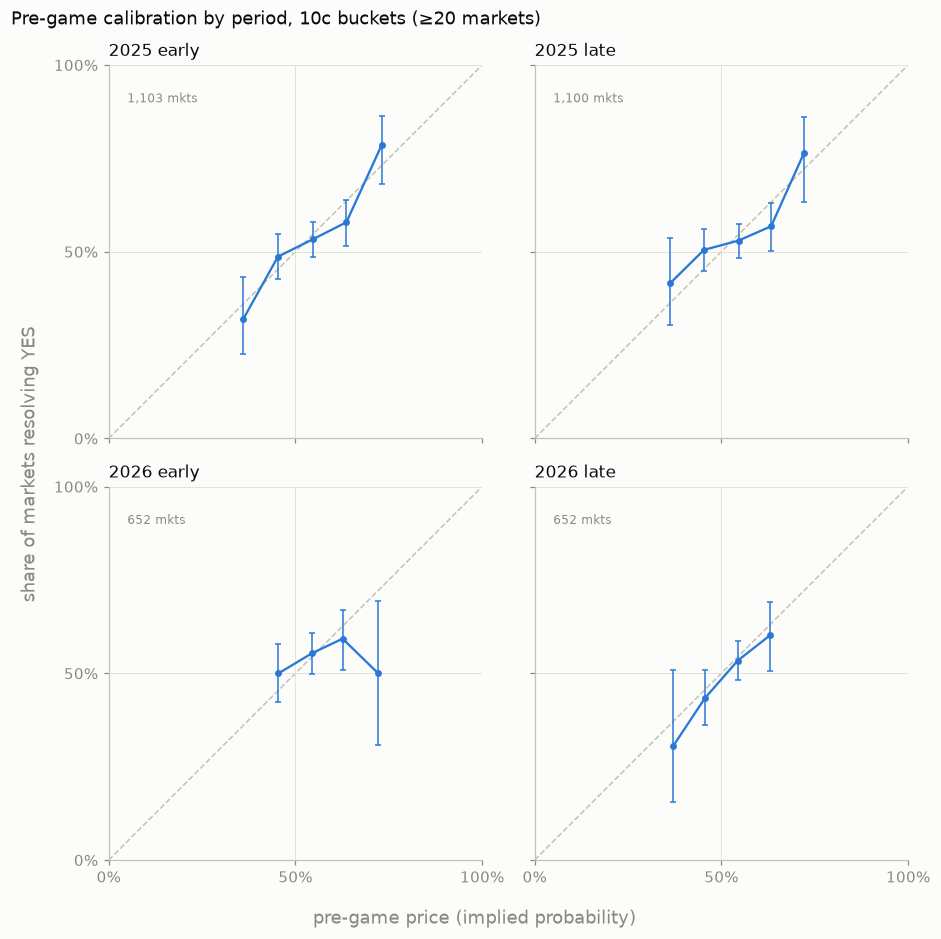

In [14]:
fig, axes = plt.subplots(2, 2, figsize=(8.6, 8.6), sharex=True, sharey=True)

for ax, (season, half) in zip(axes.flat, PERIODS):
    df = calibration("pre_snap_period", "season = ? AND half = ?",
                     buckets=10, params=[season, half])
    plot_calibration(ax, df.filter(pl.col("n_markets") >= 20))
    ax.set_title(f"{season} {half}", color=INK, fontsize=11)
    ax.annotate(f"{df['n_markets'].sum():,} mkts", (0.05, 0.9),
                xycoords="axes fraction", fontsize=8, color=MUTED)
    ax.set_xticks([0, 0.5, 1])
    ax.set_yticks([0, 0.5, 1])
    ax.xaxis.set_major_formatter(PCT)
    ax.yaxis.set_major_formatter(PCT)

fig.supxlabel("pre-game price (implied probability)", color=MUTED)
fig.supylabel("share of markets resolving YES", color=MUTED)
fig.suptitle("Pre-game calibration by period, 10c buckets (≥20 markets)",
             color=INK, x=0.01, ha="left")
fig.tight_layout()
plt.show()

In [15]:
REGIONS = [
    ("favorites 55–65¢", "p >= 0.55 AND p < 0.65"),
    ("underdogs 35–45¢", "p >= 0.35 AND p < 0.45"),
]

rows = []
for region, cond in REGIONS:
    slices = ([(f"{s} {h}", "season = ? AND half = ?", [s, h])
               for s, h in PERIODS]
              + [(f"{s} full", "season = ?", [s]) for s in (2025, 2026)])
    for label, where, params in slices:
        ap, wr, n = con.execute(f"""
            SELECT avg(p), avg(y), count(*) FROM pre_snap_period
            WHERE {where} AND {cond}
        """, params).fetchone()
        rows.append({"grp": f"{region}, {label}", "region": region,
                     "period": label, "n_markets": n,
                     "avg_price": ap, "win_rate": wr})

region_dev = with_deviation(pl.DataFrame(rows))
show_group(region_dev.rename({"grp": "region, period"}), "region, period")

"region, period",avg price,win rate,win − price,95% CI (win − price),markets
"""favorites 55–65¢, 2025 early""","""59.1¢""","""52.5%""","""-6.6¢""","""[-11.7¢, -1.5¢]""","""364"""
"""favorites 55–65¢, 2025 late""","""59.0¢""","""55.5%""","""-3.5¢""","""[-8.4¢, 1.4¢]""","""389"""
"""favorites 55–65¢, 2026 early""","""58.8¢""","""57.6%""","""-1.2¢""","""[-7.2¢, 4.6¢]""","""269"""
"""favorites 55–65¢, 2026 late""","""58.0¢""","""52.9%""","""-5.1¢""","""[-11.4¢, 1.1¢]""","""242"""
"""favorites 55–65¢, 2025 full""","""59.0¢""","""54.1%""","""-5.0¢""","""[-8.5¢, -1.4¢]""","""753"""
"""favorites 55–65¢, 2026 full""","""58.4¢""","""55.4%""","""-3.0¢""","""[-7.4¢, 1.2¢]""","""511"""
"""underdogs 35–45¢, 2025 early""","""40.5¢""","""42.4%""","""+1.9¢""","""[-5.5¢, 9.7¢]""","""158"""
"""underdogs 35–45¢, 2025 late""","""41.1¢""","""43.1%""","""+2.0¢""","""[-5.2¢, 9.6¢]""","""167"""
"""underdogs 35–45¢, 2026 early""","""41.4¢""","""50.8%""","""+9.4¢""","""[-2.5¢, 21.2¢]""","""65"""
"""underdogs 35–45¢, 2026 late""","""40.9¢""","""46.6%""","""+5.7¢""","""[-5.3¢, 17.0¢]""","""73"""


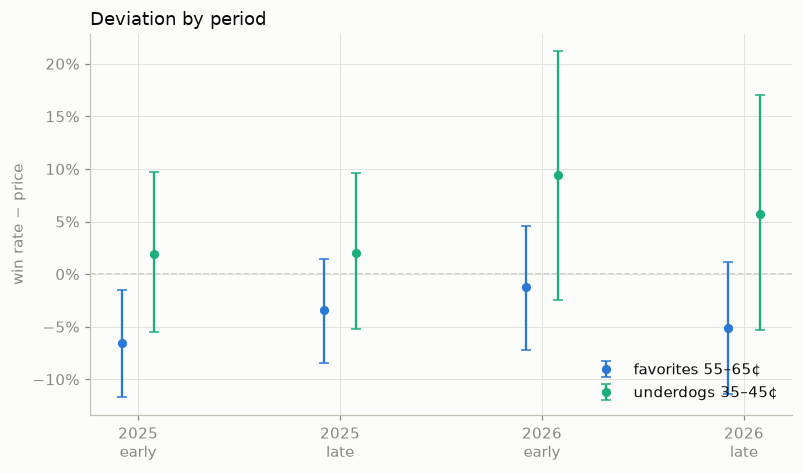

In [16]:
fig, ax = plt.subplots(figsize=(7.4, 4.4))

labels = [f"{s}\n{h}" for s, h in PERIODS]
xs = np.arange(len(PERIODS))
ax.axhline(0, ls="--", lw=1, color=BASELINE, zorder=1)

for region_name, color, dx in [("favorites 55–65¢", BLUE, -0.08),
                               ("underdogs 35–45¢", AQUA, 0.08)]:
    df = region_dev.filter(
        (pl.col("region") == region_name)
        & ~pl.col("period").str.contains("full"))
    dev = df["deviation"].to_numpy()
    yerr = np.vstack([dev - df["dev_lo"].to_numpy(),
                      df["dev_hi"].to_numpy() - dev])
    ax.errorbar(xs + dx, dev, yerr=yerr, fmt="o", ms=5, capsize=3,
                color=color, label=region_name, zorder=3)

ax.set_xticks(xs, labels)
ax.set_ylabel("win rate − price")
ax.set_title("Deviation by period", color=INK)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1, decimals=0))
ax.legend(loc="lower right", frameon=False)

fig.tight_layout()
plt.show()

## Cut 6 - Weather

Game-time weather from the MLB Stats API (`mlb_weather`): condition, temperature, wind.\
Home-side snapshots, like the rest of the notebook.\
A weather effect that pushes prices toward the home or away team shows up as a nonzero deviation.\
Note
- conditions are grouped: clear (Clear, Sunny), clouds (Partly Cloudy, Cloudy, Overcast), roof/dome (Roof Closed, Dome), rain (Rain, Drizzle)
- temperature and wind cuts only use outdoor games. domes report a constant indoor temperature and zero wind

In [17]:
con.sql("""
    CREATE OR REPLACE TEMP VIEW pre_snap_wx AS
    SELECT game_pk, p, y,
           CASE
               WHEN condition IN ('Clear', 'Sunny') THEN 'clear'
               WHEN condition IN ('Partly Cloudy', 'Cloudy', 'Overcast')
                   THEN 'clouds'
               WHEN condition IN ('Roof Closed', 'Dome') THEN 'roof/dome'
               WHEN condition IN ('Rain', 'Drizzle') THEN 'rain'
               ELSE 'other'
           END AS condition_group,
           temp_f,
           wind_mph
    FROM pre_home
""")

con.sql("""
    SELECT count(*) AS n_snapshots,
           count(*) FILTER (condition_group IS NOT NULL
                            AND condition_group != 'other') AS n_grouped,
           count(temp_f) AS n_temp,
           count(wind_mph) AS n_wind
    FROM pre_snap_wx
""").pl().select(
    fmt_count("n_snapshots").alias("pre-game snapshots"),
    fmt_count("n_grouped").alias("with condition group"),
    fmt_count("n_temp").alias("with temperature"),
    fmt_count("n_wind").alias("with wind"),
)

pre-game snapshots,with condition group,with temperature,with wind
"""3,507""","""3,507""","""3,507""","""3,507"""


In [18]:
conditions = (group_deviation("pre_snap_wx", "condition_group")
              .rename({"grp": "condition"}))
show_group(conditions, "condition")

condition,avg price,win rate,win − price,95% CI (win − price),markets
"""clear""","""54.2¢""","""55.0%""","""+0.8¢""","""[-2.2¢, 3.8¢]""","""1,058"""
"""clouds""","""53.4¢""","""51.2%""","""-2.2¢""","""[-4.5¢, 0.1¢]""","""1,839"""
"""rain""","""55.0¢""","""45.2%""","""-9.9¢""","""[-25.9¢, 7.2¢]""","""31"""
"""roof/dome""","""53.4¢""","""56.3%""","""+2.9¢""","""[-1.2¢, 6.9¢]""","""579"""


In [19]:
temps = group_deviation("pre_snap_wx", """
    CASE WHEN temp_f < 60 THEN '< 60°F'
         WHEN temp_f < 70 THEN '60–69°F'
         WHEN temp_f < 80 THEN '70–79°F'
         ELSE '80°F+' END
""", "condition_group NOT IN ('roof/dome') AND temp_f IS NOT NULL",
    order_by="min(temp_f)").rename({"grp": "temperature (outdoor)"})
show_group(temps, "temperature (outdoor)")

temperature (outdoor),avg price,win rate,win − price,95% CI (win − price),markets
"""< 60°F""","""53.7¢""","""52.6%""","""-1.1¢""","""[-6.7¢, 4.4¢]""","""308"""
"""60–69°F""","""54.6¢""","""51.6%""","""-3.0¢""","""[-6.9¢, 0.8¢]""","""645"""
"""70–79°F""","""54.1¢""","""55.6%""","""+1.5¢""","""[-1.5¢, 4.5¢]""","""1,054"""
"""80°F+""","""52.7¢""","""49.6%""","""-3.0¢""","""[-6.3¢, 0.2¢]""","""921"""


In [20]:
winds = group_deviation("pre_snap_wx", """
    CASE WHEN wind_mph < 5 THEN '0–4 mph'
         WHEN wind_mph < 10 THEN '5–9 mph'
         ELSE '10+ mph' END
""", "condition_group NOT IN ('roof/dome') AND wind_mph IS NOT NULL",
    order_by="min(wind_mph)").rename({"grp": "wind (outdoor)"})
show_group(winds, "wind (outdoor)")

wind (outdoor),avg price,win rate,win − price,95% CI (win − price),markets
"""0–4 mph""","""54.0¢""","""53.3%""","""-0.7¢""","""[-5.0¢, 3.5¢]""","""527"""
"""5–9 mph""","""53.5¢""","""52.4%""","""-1.0¢""","""[-3.5¢, 1.5¢]""","""1,535"""
"""10+ mph""","""54.0¢""","""52.2%""","""-1.8¢""","""[-5.1¢, 1.6¢]""","""866"""


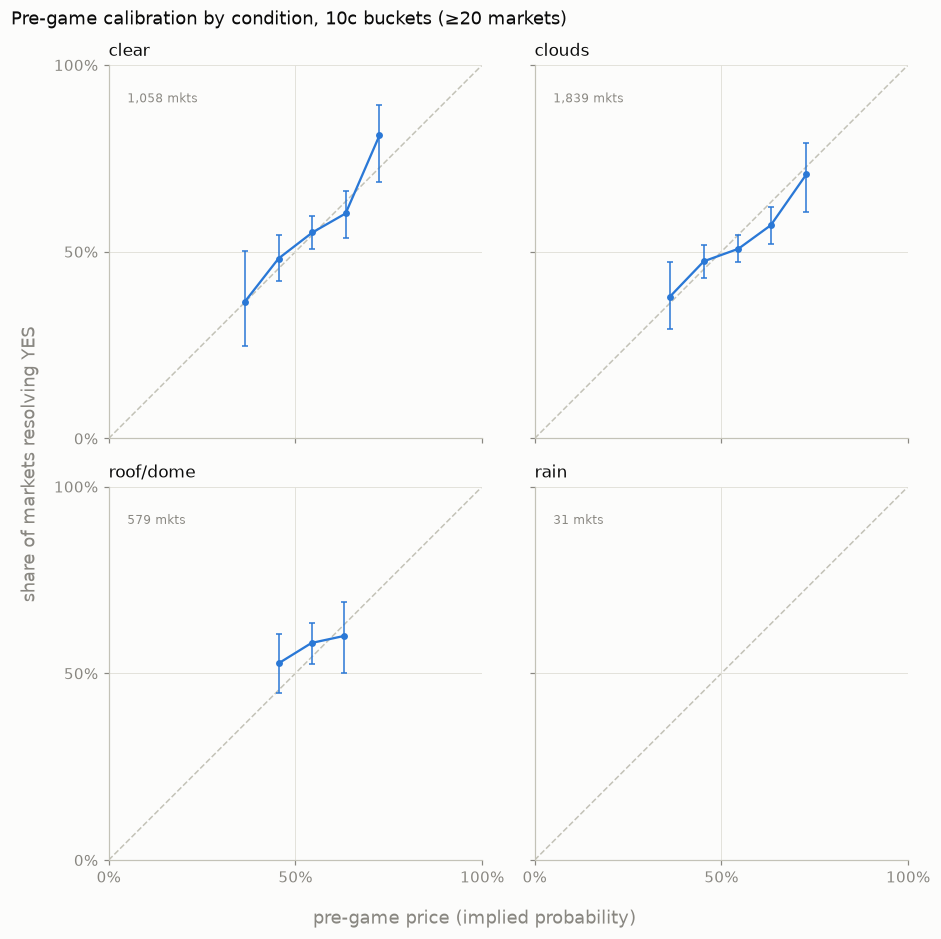

In [21]:
# home-side calibration curves per condition group
fig, axes = plt.subplots(2, 2, figsize=(8.6, 8.6), sharex=True, sharey=True)

for ax, grp in zip(axes.flat, ["clear", "clouds", "roof/dome", "rain"]):
    df = calibration("pre_snap_wx", "condition_group = ?", buckets=10,
                     params=[grp])
    plot_calibration(ax, df.filter(pl.col("n_markets") >= 20))
    ax.set_title(grp, color=INK, fontsize=11)
    ax.annotate(f"{df['n_markets'].sum():,} mkts", (0.05, 0.9),
                xycoords="axes fraction", fontsize=8, color=MUTED)
    ax.set_xticks([0, 0.5, 1])
    ax.set_yticks([0, 0.5, 1])
    ax.xaxis.set_major_formatter(PCT)
    ax.yaxis.set_major_formatter(PCT)

fig.supxlabel("pre-game price (implied probability)", color=MUTED)
fig.supylabel("share of markets resolving YES", color=MUTED)
fig.suptitle("Pre-game calibration by condition, 10c buckets "
             "(≥20 markets)", color=INK, x=0.01, ha="left")
fig.tight_layout()
plt.show()

No weather group deviates significantly.\
Deviations by condition group are clear +0.8c, clouds -2.2c, roof/dome +2.9c, and rain -9.9c on only 31 games. Every CI includes zero.\
Temperature and wind bands likewise (largest deviation -3.0c, all intervals spanning zero).\
Eleven intervals were tested at 95%, so even one exclusion would have been unremarkable. There were none.\
The condition-group calibration curves sit on the diagonal wherever the sample supports a read.

## A Bucket-Free Test - Calibration Regression

The bucket findings above have two weaknesses.
- the bucket boundaries were chosen after looking at the curve
- roughly ten buckets were tested at 95%, so a significant one or two is expected by chance

A calibration regression avoids both.\
Fit the win outcome against the log-odds of the pre-game price. Same observations as Cut 1: one home-side snapshot per game.\
No buckets, no boundaries.\
Perfect calibration means slope = 1. Prices too extreme relative to outcomes means slope < 1.

Two weaknesses it does *not* avoid.
- the regressor is a noisy last-trade price, and noise in a regressor biases the slope below 1, the same direction as the hypothesis. appendix D measures this and finds it far too small to matter
- it is run on the same data that suggested the hypothesis. a slope below 1 is consistent with the bucket pattern being real, but it is not independent confirmation. only future games can provide that

In [22]:
import math


def logit_fit(p, y):
    """IRLS logistic fit of y on [1, logit(p)]; returns coefs and SEs."""
    x = np.log(p / (1 - p))
    X = np.column_stack([np.ones_like(x), x])
    beta = np.zeros(2)
    for _ in range(50):
        eta = X @ beta
        mu = 1 / (1 + np.exp(-eta))
        w = mu * (1 - mu)
        z = eta + (y - mu) / w
        XtW = X.T * w
        new = np.linalg.solve(XtW @ X, XtW @ z)
        if np.max(np.abs(new - beta)) < 1e-10:
            beta = new
            break
        beta = new
    cov = np.linalg.inv((X.T * (mu * (1 - mu))) @ X)
    return beta, np.sqrt(np.diag(cov))


rows = []
for label, where in [("all games", "TRUE"),
                     ("2025 only", "season = 2025"),
                     ("2026 only", "season = 2026")]:
    d = con.sql(f"SELECT p, y FROM pre_snap_period WHERE {where}").fetchnumpy()
    (a, b), (se_a, se_b) = logit_fit(d["p"], d["y"].astype(float))
    z = (b - 1) / se_b
    p_onesided = 0.5 * (1 + math.erf(z / math.sqrt(2)))
    rows.append({
        "slice": label,
        "games": f"{len(d['p']):,}",
        "intercept": f"{a:+.3f} (se {se_a:.3f})",
        "slope": f"{b:.3f} (se {se_b:.3f})",
        "P(slope < 1 | calibrated)": f"{p_onesided:.3f}",
    })
pl.DataFrame(rows)

slice,games,intercept,slope,P(slope < 1 | calibrated)
"""all games""","""3,507""","""+0.010 (se 0.037)""","""0.781 (se 0.092)""","""0.009"""
"""2025 only""","""2,203""","""+0.011 (se 0.046)""","""0.816 (se 0.111)""","""0.049"""
"""2026 only""","""1,304""","""+0.011 (se 0.060)""","""0.700 (se 0.164)""","""0.033"""


## Costs - Calibrated vs Exploitable

A deviation is only interesting if it survives the cost of trading it.\
Exploiting one means buying the underpriced side as a taker and holding to settlement (settlement is free).\
The cost
- taker fee: 7c × p × (1−p) per contract (`wiki/kalshi-fees.md`)
- half the one-tick spread (appendix C)

That comes to about 2.2c in the mid-range where MLB games trade, the most expensive zone of Kalshi's fee curve.\
A bucket is evidence of a tradeable edge only if its entire deviation CI lies outside that cost band.

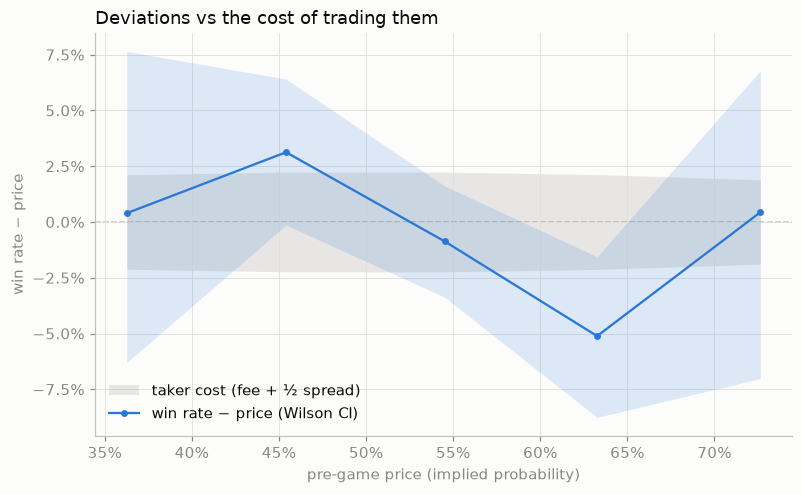

price range,avg price,win rate,win − price,95% CI (win − price),markets,taker cost,CI clears cost
"""30–40¢""","""36.3¢""","""36.7%""","""+0.4¢""","""[-6.3¢, 7.6¢]""","""180""","""2.1¢""",""""""
"""40–50¢""","""45.4¢""","""48.5%""","""+3.1¢""","""[-0.1¢, 6.4¢]""","""892""","""2.2¢""",""""""
"""50–60¢""","""54.5¢""","""53.7%""","""-0.9¢""","""[-3.4¢, 1.6¢]""","""1,532""","""2.2¢""",""""""
"""60–70¢""","""63.3¢""","""58.2%""","""-5.1¢""","""[-8.8¢, -1.6¢]""","""717""","""2.1¢""",""""""
"""70–80¢""","""72.6¢""","""73.1%""","""+0.4¢""","""[-7.0¢, 6.8¢]""","""156""","""1.9¢""",""""""


In [23]:
# taker cost to exploit a deviation: fee (wiki/kalshi-fees.md) plus half
# the one-tick spread (appendix C); settlement is free
HALF_SPREAD = 0.005

cost = overall.filter(pl.col("n_markets") >= 30).with_columns(
    (0.07 * pl.col("avg_price") * (1 - pl.col("avg_price")) + HALF_SPREAD)
        .alias("taker_cost"),
).with_columns(
    ((pl.col("dev_lo") > pl.col("taker_cost"))
     | (pl.col("dev_hi") < -pl.col("taker_cost")))
        .alias("clears"),
)

fig, ax = plt.subplots(figsize=(7.4, 4.6))
x = cost["avg_price"].to_numpy()
dev = cost["deviation"].to_numpy()
lo = cost["dev_lo"].to_numpy()
hi = cost["dev_hi"].to_numpy()
band = cost["taker_cost"].to_numpy()
ax.axhline(0, ls="--", lw=1, color=BASELINE, zorder=1)
ax.fill_between(x, -band, band, color=MUTED, alpha=0.18, lw=0, zorder=1,
                label="taker cost (fee + ½ spread)")
ax.fill_between(x, lo, hi, color=BLUE, alpha=0.15, lw=0, zorder=2)
ax.plot(x, dev, "o-", ms=3.5, lw=1.5, color=BLUE, zorder=3,
        label="win rate − price (Wilson CI)")
ax.set_xlabel("pre-game price (implied probability)")
ax.set_ylabel("win rate − price")
ax.set_title("Deviations vs the cost of trading them", color=INK)
ax.xaxis.set_major_formatter(PCT)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1, decimals=1))
ax.legend(loc="lower left", frameon=False)
fig.tight_layout()
plt.show()

show_calibration(cost).hstack(cost.select(
    fmt_cents("taker_cost").alias("taker cost"),
    pl.when(pl.col("clears")).then(pl.lit("yes")).otherwise(pl.lit(""))
        .alias("CI clears cost"),
))

No bucket clears the band.\
The only significant bucket, 60-70c favorites (deviation -5.1c, CI [-8.8c, -1.6c], cost ~2.1c), is worth ~3c per contract at face value, but the near edge of its CI sits inside the cost band.\
The regression-implied mispricing, ~2c in the toss-up range, sits below the ~2.2c cost to trade it.\
Note
- resting maker orders lower the bar. the fee drops to a quarter and the half-spread is earned rather than paid. the price is fill risk and adverse selection, which trade data cannot measure

Either way, nothing here is tradeable: the believable effect (the regression's ~2c) is below cost even at face value, and the one bucket whose face value beats cost has no statistical support (CI inside the band, post-hoc boundaries).

## Findings

**In-game prices are well calibrated.**\
Across the nine entering-inning tables, 5 of 86 buckets' CIs exclude zero, roughly the false-positive rate of 95% intervals, with no pattern in where they land.\
Entering extras is the thinnest slice (302 markets) and shows nothing significant.

**No team stands out beyond chance.**\
Two of thirty teams' deviation intervals exclude zero (Milwaukee +6.4c, New York M -8.2c).\
At 95% confidence, that is roughly what noise produces across thirty tests.\
The team × home/away screen agrees: 2 of 60 cells flagged (New York M away, Washington away), no team flagged on both sides.

**Home/away shows no aggregate bias.**\
Home -0.5c and away -0.6c, neither significant.\
An earlier volume-weighted per-trade version of this analysis flagged home mid-range markets as significantly overpriced. That result did not survive the switch to one observation per market. A caution against reading too much into any single cut here.

**The pre-game compression pattern is judged noise.**\
The bucket view flags one bucket: 60-70c favorites at -5.1c.\
Reasons to distrust the bucket view
- the bucket boundaries were chosen after looking
- ~10 buckets were tested, so one exclusion is close to the false-positive rate

The regression, which has neither problem, estimates slope 0.781 (se 0.092) against 1.0 for perfect calibration. About a 1% chance of a value this low if prices were calibrated, with both seasons pointing the same direction (0.82 and 0.70) and the favorites' deviation negative in all four season halves.\
Last-trade noise does not explain it (appendix D). Refitting on the median of each game's last three pre-game trades gives slope 0.786, and simulating perfectly calibrated outcomes with 1c of price noise leaves the average slope at 0.994.\
But
- the test was run on the same data that suggested the hypothesis
- the implied mispricing is only ~2c in the toss-up range
- a season and a half of one sport is a small sample for an effect this size
- with costs netted (above), even the face-value effect is untradeable, so the question is not worth an out-of-sample campaign

The project verdict: noise.

**Weather shows no pricing effect.**\
Deviations by condition group (clear, clouds, roof/dome, rain), temperature band, and wind speed all have CIs that include zero. Eleven intervals, none significant.\
The rain group is 31 games and says nothing either way.

**Costs beat the deviations.**\
Netting the taker fee plus half the one-tick spread (~2.2c in the mid-range) against the curve, no bucket's CI clears the cost band — the only significant bucket (60-70c) has a CI near edge of -1.6c against a ~2.1c cost.\
The regression-implied ~2c toss-up mispricing does not clear it either.

## Held for a Second Pass

- liquidity tiers
- trade size
- taker side
- day/night

Descoped: time-to-close buckets within pre-game.

## Appendix A - No-Arbitrage Check

Each game has two markets, one per team, each with its own order book.\
If the books are consistent the two pre-game snapshots should sum to about $1.\
They do. The median of p_home + p_away is 101c, 73% of games land within 2c of $1, and only 16 of 3,507 land beyond 5c.\
So the away market is the home market's mirror and carries no extra information. The analysis keeps the home side.\
Note
- the two snapshots are last trades from two separate books, possibly minutes apart, and each prints at its book's bid or ask. a cent or two of slack is expected, and a stale leg explains sums further out
- a fat tail far from $1 would have been a finding in its own right (free arbitrage). 16 games of 3,507 is not one

In [24]:
totals = con.sql("""
    SELECT game_pk, sum(p) AS total
    FROM mlb_calib_pre_snapshots
    GROUP BY game_pk
    HAVING count(*) = 2
""")
con.sql("""
    SELECT count(*) AS n_games,
           median(total) AS med_total,
           count(*) FILTER (abs(total - 1) <= 0.01) AS within_1c,
           count(*) FILTER (abs(total - 1) <= 0.02) AS within_2c,
           count(*) FILTER (abs(total - 1) > 0.05) AS beyond_5c,
           min(total) AS min_total,
           max(total) AS max_total
    FROM totals
""").pl().select(
    fmt_count("n_games").alias("games with both snapshots"),
    fmt_cents("med_total").alias("median p_home + p_away"),
    fmt_count("within_1c").alias("within 1¢ of $1"),
    fmt_count("within_2c").alias("within 2¢"),
    fmt_count("beyond_5c").alias("beyond 5¢"),
    fmt_cents("min_total").alias("min"),
    fmt_cents("max_total").alias("max"),
)

games with both snapshots,median p_home + p_away,within 1¢ of $1,within 2¢,beyond 5¢,min,max
"""3,507""","""101.0¢""","""537""","""2,566""","""16""","""96.5¢""","""118.0¢"""


## Appendix B - Snapshot Freshness

How old is the pre-game snapshot at first pitch?\
Fresh: median age 1 minute, p90 5 minutes, p99 29 minutes.\
Every game in the universe has a home-side trade inside the 24 hour window.\
So the exact definition of "shortly before the game" barely matters.

In [25]:
con.sql("""
    SELECT count(*) AS n_snapshots,
           (SELECT n_games FROM mlb_calib_build_info) - count(*)
               AS n_missing,
           quantile_cont(mins, 0.5) AS median_mins,
           quantile_cont(mins, 0.9) AS p90_mins,
           quantile_cont(mins, 0.99) AS p99_mins
    FROM (
        SELECT date_diff('minute', created_time, sched_start) AS mins
        FROM pre_home
    )
""").pl().select(
    fmt_count("n_snapshots").alias("pre-game snapshots"),
    fmt_count("n_missing").alias("games with no trade in window"),
    pl.format("{} min", pl.col("median_mins").cast(pl.Int64))
        .alias("median age at first pitch"),
    pl.format("{} min", pl.col("p90_mins").cast(pl.Int64)).alias("p90"),
    pl.format("{} min", pl.col("p99_mins").cast(pl.Int64)).alias("p99"),
)

pre-game snapshots,games with no trade in window,median age at first pitch,p90,p99
"""3,507""","""0""","""1 min""","""5 min""","""29 min"""


## Appendix C - Effective Spread Check

Trades print at the bid or the ask, never in between.\
A taker buying YES prints at the ask, a taker selling YES prints at the bid (`taker_outcome_side`).\
So if spreads were wide, a last-trade snapshot could sit up to half a spread away from the market's actual estimate, and that alone could look like miscalibration.

The check: per game, the gap between the last taker-bought-YES print and the last taker-sold-YES print on the home-side market in the pre-game window.\
This gap is a proxy for the spread.\
The result: one tick. median gap 1c, 90th percentile 2c, 92 of 3,392 games above 3c.\
So a print sits at most about half a cent from the market's estimate in the typical game. That half cent is the number the Costs section uses.\
Note
- the two legs can be minutes apart, so a market that moved in between can make the gap zero or negative

In [26]:
con.sql("""
    CREATE OR REPLACE TEMP VIEW spread_legs AS
    SELECT game_pk,
           max(p) FILTER (taker_outcome_side = 'yes') AS ask_proxy,
           max(p) FILTER (taker_outcome_side = 'no') AS bid_proxy
    FROM (
        SELECT game_pk, p, taker_outcome_side, created_time
        FROM mlb_calib_pre_window_trades
        WHERE side = 'home'
        QUALIFY row_number() OVER (
            PARTITION BY game_pk, taker_outcome_side
            ORDER BY created_time DESC) = 1
    )
    GROUP BY game_pk
""")

con.sql("""
    SELECT count(*) AS n_games,
           count(gap) AS n_both_sides,
           median(gap) AS med_gap,
           quantile_cont(gap, 0.9) AS p90_gap,
           count(*) FILTER (gap > 0.03) AS n_wide,
           count(*) FILTER (gap < 0) AS n_crossed
    FROM (SELECT ask_proxy - bid_proxy AS gap FROM spread_legs)
""").pl().select(
    fmt_count("n_games").alias("games"),
    fmt_count("n_both_sides").alias("both sides traded"),
    fmt_cents("med_gap").alias("median gap"),
    fmt_cents("p90_gap").alias("p90 gap"),
    fmt_count("n_wide").alias("gap > 3¢"),
    fmt_count("n_crossed").alias("gap < 0 (market moved)"),
)

games,both sides traded,median gap,p90 gap,gap > 3¢,gap < 0 (market moved)
"""3,507""","""3,392""","""1.0¢""","""2.0¢""","""92""","""48"""


## Appendix D - Regression Robustness

The regressor is the last trade's price, which carries bid-ask bounce and 1c tick discreteness.\
Noise in a regressor pulls the fitted slope toward zero, the same direction as the finding.\
So two checks
- re-fit on the median of the last three pre-game trades (less bounce)
- simulate how far 1c of uniform price noise pulls the slope below 1 when outcomes are drawn from perfectly calibrated probabilities

In [27]:
d3 = con.sql("""
    WITH last3 AS (
        SELECT game_pk, p, y
        FROM mlb_calib_pre_window_trades
        WHERE side = 'home'
        QUALIFY row_number() OVER (
            PARTITION BY game_pk
            ORDER BY created_time DESC) <= 3
    )
    SELECT median(p) AS p, any_value(y) AS y
    FROM last3 GROUP BY game_pk
""").fetchnumpy()
(a3, b3), (_, se_b3) = logit_fit(d3["p"], d3["y"].astype(float))
print(f"median-of-last-3 slope: {b3:.3f} (se {se_b3:.3f}) "
      f"on {len(d3['p']):,} games")

median-of-last-3 slope: 0.786 (se 0.093) on 3,507 games


In [28]:
rng = np.random.default_rng(0)
p = con.sql("SELECT p FROM pre_snap_period").fetchnumpy()["p"]
slopes = []
for _ in range(200):
    y_sim = (rng.random(p.size) < p).astype(float)
    noisy = np.clip(p + rng.uniform(-0.01, 0.01, p.size), 0.01, 0.99)
    (_, b_sim), _ = logit_fit(noisy, y_sim)
    slopes.append(b_sim)
slopes = np.array(slopes)
print(f"simulated slope under perfect calibration + 1c noise: "
      f"mean {slopes.mean():.3f}, "
      f"5th percentile {np.percentile(slopes, 5):.3f}")

simulated slope under perfect calibration + 1c noise: mean 0.994, 5th percentile 0.833
